# Section 5: Fiscal Policy Experiments Notebook
This notebook studies how government spending shocks affect a macroeconomy.


## Parameters and Imports
This section loads libraries and sets the model's fixed numbers (parameters).

What these parameters mean in simple terms:
- `beta`: how patient households are (higher means more future-oriented).
- `sigma`: how strongly households dislike consumption fluctuations.
- `phi`: how responsive labor supply is to incentives.
- `alpha`: the share of output paid to capital.
- `delta`: how fast capital wears out each period.
- `z_sim`: productivity level used in Section 3.2 baseline run.
- Section 3.3 productivity states (`zL`, `zH`) use a two-state aggregate productivity calibration: `zL = 0.99`, `zH = 1.01`, with transition matrix `[[0.875, 0.125], [0.125, 0.875]]`.
- `g_y_ratio`: normal government spending as a share of output.
- `shock_size`: size of the government spending shock.
- `T`: number of periods simulated after the shock.

These values act like the "settings" for the entire simulation.


In [19]:
# Section 3.2
import numpy as np
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# =============================================================================
# 1. PARAMETERS
# =============================================================================

beta      = 0.984
sigma     = 1.0
phi       = 1.0
alpha     = 0.33
delta     = 0.025
g_y_ratio = 0.20
target_L  = 1.0 / 3.0

# Target_L is used only to calibrate chi and seed solvers. Labor remains endogenous
# in both the VFI and the transition-path solver below.
calibration_z = 1.0
z_states = np.array([0.99, 1.01])  # state order: [zL, zH]
z_L, z_H = float(z_states[0]), float(z_states[1])
z_sim = z_H                       # Section 3.2 uses one productivity state; pick zH.

P_z = np.array([
    [0.875, 0.125],
    [0.125, 0.875],
])
P = P_z  # friend-code compatibility alias

# Grids used by the endogenous-labor VFI policy map.
k_grid_size = 200
k_grid = np.linspace(1.0, 25.0, k_grid_size)
labor_grid_size = 151
labor_grid = np.linspace(0.05, 0.95, labor_grid_size)
params_vfi = (beta, sigma, phi, alpha, delta, g_y_ratio)

T_PRE_FOR  = 4
T_DYN_FOR  = 36
T_PRE_UNF  = 5
T_DYN_UNF  = 35

GROUND_ZERO_FORESEEN   = 4
GROUND_ZERO_UNFORESEEN = 5

SHOCK_SIZES    = [0.01, 0.05, 0.10]
FORESEEN_LEADS = [1, 5, 9]
BENCHMARK_LEAD = 5
BENCHMARK_SIZE = 0.10

# Compatibility aliases used by Section 3.3 cells
T = T_PRE_FOR + T_DYN_FOR  # 40 -> time grid 0..40
shock_size = BENCHMARK_SIZE
foreseen_shock_date = GROUND_ZERO_UNFORESEEN
foreseen_announce_date = GROUND_ZERO_FORESEEN


## Core Model Equations
This section defines the economy's basic production relationships.

Equations here do three jobs:
- `production_function`: turns capital (`K`) and labor (`L`) into output (`Y`) using productivity (`z`).
- `marginal_product_labor`: gives the real wage (`w`) from one extra unit of labor.
- `marginal_product_capital`: gives the return to capital (`rk`) from one extra unit of capital.


In [20]:
# 2. Core model equations

def production_function(K, L, z):
    return z * (K ** alpha) * (L ** (1 - alpha))

def marginal_product_labor(K, L, z):
    return (1 - alpha) * z * (K ** alpha) * (L ** (-alpha))

def marginal_product_capital(K, L, z):
    return alpha * z * (K ** (alpha - 1)) * (L ** (1 - alpha))


## Steady-State Calibration and Solver
This section finds the model's "normal" long-run point (steady state).

What happens step-by-step:
1. `calibrate_chi` chooses the labor disutility parameter `chi` so steady-state labor matches the target (`L = 1/3`).
2. `steady_state_fixed_G_equations` writes the three steady-state conditions:
   - Euler equation (intertemporal optimality),
   - labor first-order condition,
   - resource constraint (`Y = C + I + G`).
3. `solve_steady_state_fixed_G` uses `fsolve` to solve for steady-state `K`, `L`, and `C`.


In [21]:
# 3. Steady state

def period_utility(C, L, chi):
    C_arr = np.asarray(C, dtype=float)
    L_arr = np.asarray(L, dtype=float)
    C_safe = np.maximum(C_arr, 1e-12)

    if sigma == 1.0:
        u_c = np.log(C_safe)
    else:
        u_c = (C_safe ** (1.0 - sigma) - 1.0) / (1.0 - sigma)

    disutility_l = chi * (L_arr ** (1.0 + phi)) / (1.0 + phi)
    return np.where(C_arr > 1e-10, u_c - disutility_l, -1e15)


def calibrate_chi(z=1.0, L_target=1/3, K_guess=10.0):
    def euler_eq(K_arr):
        K = K_arr[0]
        if K <= 0:
            return [1e6]
        rk = marginal_product_capital(K, L_target, z)
        return [1.0 - beta * (rk + 1.0 - delta)]

    K_ss = fsolve(euler_eq, [K_guess])[0]
    Y_ss = production_function(K_ss, L_target, z)
    I_ss = delta * K_ss
    G_ss = g_y_ratio * Y_ss
    C_ss = Y_ss - I_ss - G_ss

    if C_ss <= 0:
        raise ValueError("Calibration failed: C_ss <= 0.")

    w_ss = marginal_product_labor(K_ss, L_target, z)
    chi  = w_ss * (C_ss ** (-sigma)) / (L_target ** phi)
    return {"chi": chi, "K": K_ss, "L": L_target,
            "C": C_ss, "Y": Y_ss, "I": I_ss, "G": G_ss}


def steady_state_eqs(vars, z, chi, G_fixed):
    K, L, C = vars
    if K <= 0 or L <= 0 or C <= 0:
        return [1e6, 1e6, 1e6]
    Y  = production_function(K, L, z)
    w  = marginal_product_labor(K, L, z)
    rk = marginal_product_capital(K, L, z)
    return [1.0 - beta * (rk + 1.0 - delta),
            chi * (L ** phi) - w * (C ** (-sigma)),
            Y - C - delta * K - G_fixed]


def solve_steady_state(z, chi, G_fixed, guess=(10.0, 0.33, 1.0)):
    K, L, C = fsolve(steady_state_eqs, guess, args=(z, chi, G_fixed))
    Y = production_function(K, L, z)
    return {"K": K, "L": L, "C": C, "Y": Y, "I": delta * K,
            "G": G_fixed, "w": marginal_product_labor(K, L, z),
            "rk": marginal_product_capital(K, L, z)}


def steady_state_gy_ratio_eqs(vars, z, chi):
    K, L, C = vars
    if K <= 0 or L <= 0 or C <= 0:
        return [1e6, 1e6, 1e6]
    Y = production_function(K, L, z)
    G = g_y_ratio * Y
    w = marginal_product_labor(K, L, z)
    rk = marginal_product_capital(K, L, z)
    return [1.0 - beta * (rk + 1.0 - delta),
            chi * (L ** phi) - w * (C ** (-sigma)),
            Y - C - delta * K - G]


def solve_steady_state_gy_ratio(z, chi, guess=(10.0, 0.33, 1.0)):
    """Steady state with the baseline rule G/Y = g_y_ratio."""
    K, L, C = fsolve(steady_state_gy_ratio_eqs, guess, args=(z, chi))
    Y = production_function(K, L, z)
    G = g_y_ratio * Y
    return {"K": K, "L": L, "C": C, "Y": Y, "I": delta * K,
            "G": G, "w": marginal_product_labor(K, L, z),
            "rk": marginal_product_capital(K, L, z)}


# Compatibility wrappers used in Section 3.3 cells
def steady_state_fixed_G_equations(vars, z, chi, G_fixed):
    return steady_state_eqs(vars, z, chi, G_fixed)

def solve_steady_state_fixed_G(z, chi, G_fixed, initial_guess=(10.0, 0.33, 1.0)):
    return solve_steady_state(z, chi, G_fixed, guess=initial_guess)


In [22]:
# 4. Find baseline/reference steady state

calib = calibrate_chi(z=calibration_z, L_target=target_L)
chi = calib["chi"]

# Section 3.2 is conditional on one productivity state. Use zH while keeping chi
# calibrated at the neutral productivity level so target_L remains an economy-wide
# calibration target, not a fixed labor choice.
ss_ref = solve_steady_state_gy_ratio(
    z_sim,
    chi,
    guess=(calib["K"], calib["L"], calib["C"]),
)

# Compatibility aliases used by later cells
calib_results = calib
ss_baseline = ss_ref

print("=" * 55)
print("BASELINE STEADY STATE")
print("=" * 55)
print(f"  calibration_z: {calibration_z:.4f}")
print(f"  z_sim       : {z_sim:.4f}")
for k, v in ss_ref.items():
    print(f"  {k:<6}: {v:.4f}")
print(f"  {'chi':<6}: {chi:.4f}")
print()
print(f"Foreseen  : announced t={GROUND_ZERO_FORESEEN}, "
      f"G hits t={GROUND_ZERO_FORESEEN+1}/"
      f"t={GROUND_ZERO_FORESEEN+5}/"
      f"t={GROUND_ZERO_FORESEEN+9}")
print(f"Unforeseen: G hits t={GROUND_ZERO_UNFORESEEN} (no prior notice)")
print(f"Benchmark : {int(BENCHMARK_SIZE*100)}% shock, lead={BENCHMARK_LEAD}Q "
      f"(G hits t={GROUND_ZERO_FORESEEN+BENCHMARK_LEAD})")


BASELINE STEADY STATE
  calibration_z: 1.0000
  z_sim       : 1.0100
  K     : 7.5347
  L     : 0.3333
  C     : 0.5653
  Y     : 0.9421
  I     : 0.1884
  G     : 0.1884
  w     : 1.8936
  rk    : 0.0413
  chi   : 10.0492

Foreseen  : announced t=4, G hits t=5/t=9/t=13
Unforeseen: G hits t=5 (no prior notice)
Benchmark : 10% shock, lead=5Q (G hits t=9)


## VFI Policy Map
This section solves the household Bellman problem on a \((k,z)\) grid with endogenous labor.  
For each \((z,k,k')\), labor is optimized first to build one-period returns, then VFI selects the optimal \(k'\) using expected continuation values from the Markov matrix \(P\).  
The outputs are state-contingent policy maps \(V(k,z)\), \(k'(k,z)\), \(c(k,z)\), and \(l(k,z)\), used for diagnostics and Section 3.3 comparisons.


In [23]:
# 4A. Endogenous-labor VFI policy map from the two-state productivity process

def precompute_vfi_returns(chi, z_states, k_grid, labor_grid, G_by_state):
    """
    For each (z, k, k') pair, maximize current-period utility over labor.
    Government purchases are fixed by productivity state, so the household does
    not internalize G moving with its own labor choice.
    """
    n_z = len(z_states)
    n_k = len(k_grid)
    returns = np.empty((n_z, n_k, n_k))
    labor_star = np.empty((n_z, n_k, n_k))
    consumption_star = np.empty((n_z, n_k, n_k))
    labor_choices = labor_grid[:, None]

    for i_z, z in enumerate(z_states):
        G_fixed = G_by_state[i_z]
        for i_k, k in enumerate(k_grid):
            Y = z * (k ** alpha) * (labor_choices ** (1.0 - alpha))
            C = Y + (1.0 - delta) * k - k_grid[None, :] - G_fixed
            U = period_utility(C, labor_choices, chi)
            best_l_idx = np.argmax(U, axis=0)
            kp_idx = np.arange(n_k)

            returns[i_z, i_k, :] = U[best_l_idx, kp_idx]
            labor_star[i_z, i_k, :] = labor_grid[best_l_idx]
            consumption_star[i_z, i_k, :] = C[best_l_idx, kp_idx]

    return returns, labor_star, consumption_star


def solve_endogenous_labor_vfi(
    chi,
    P,
    z_states,
    k_grid,
    labor_grid,
    G_by_state,
    beta=beta,
    tol=1e-5,
    max_iter=1200,
    stable_policy_iter=25,
    min_iter=900,
):
    n_k = len(k_grid)
    n_z = len(z_states)
    returns, labor_by_choice, consumption_by_choice = precompute_vfi_returns(
        chi, z_states, k_grid, labor_grid, G_by_state
    )

    V = np.zeros((n_k, n_z))
    policy_idx = np.zeros((n_k, n_z), dtype=int)
    previous_policy_idx = None
    stable_count = 0
    final_diff = np.inf
    criterion = "max_iter"

    for iteration in range(1, max_iter + 1):
        V_old = V.copy()
        EV = V_old @ P.T

        for i_z in range(n_z):
            V_mat = returns[i_z] + beta * EV[None, :, i_z]
            V[:, i_z] = np.max(V_mat, axis=1)
            policy_idx[:, i_z] = np.argmax(V_mat, axis=1)

        final_diff = float(np.max(np.abs(V - V_old)))
        if previous_policy_idx is not None and np.array_equal(policy_idx, previous_policy_idx):
            stable_count += 1
        else:
            stable_count = 0
            previous_policy_idx = policy_idx.copy()

        if final_diff < tol:
            criterion = "value_tol"
            break
        if iteration >= min_iter and stable_count >= stable_policy_iter:
            criterion = "policy_stable"
            break

    k_policy = k_grid[policy_idx]
    c_policy = np.empty((n_k, n_z))
    l_policy = np.empty((n_k, n_z))
    row_idx = np.arange(n_k)
    for i_z in range(n_z):
        c_policy[:, i_z] = consumption_by_choice[i_z, row_idx, policy_idx[:, i_z]]
        l_policy[:, i_z] = labor_by_choice[i_z, row_idx, policy_idx[:, i_z]]

    return {
        "V": V,
        "policy_idx": policy_idx,
        "k_policy": k_policy,
        "c_policy": c_policy,
        "l_policy": l_policy,
        "returns": returns,
        "iterations": iteration,
        "final_diff": final_diff,
        "criterion": criterion,
    }


def policy_fixed_point(k_grid, policy, state_idx, guess=None):
    """Approximate k = g(k,z) by grid crossing/nearest-grid residual."""
    diff = policy[:, state_idx] - k_grid
    exact = np.where(np.isclose(diff, 0.0, atol=1e-10))[0]
    if len(exact) > 0:
        if guess is None:
            return float(k_grid[exact[0]])
        return float(k_grid[exact[np.argmin(np.abs(k_grid[exact] - guess))]])

    roots = []
    crossings = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    for idx in crossings:
        x0, x1 = k_grid[idx], k_grid[idx + 1]
        y0, y1 = diff[idx], diff[idx + 1]
        if np.isclose(y1, y0):
            roots.append(float(x0))
        else:
            roots.append(float(x0 - y0 * (x1 - x0) / (y1 - y0)))

    if roots:
        if guess is None:
            return roots[0]
        return float(roots[int(np.argmin(np.abs(np.array(roots) - guess)))])

    if guess is None:
        idx = int(np.argmin(np.abs(diff)))
    else:
        # Prefer the point near the analytical steady state if no crossing exists.
        local_weight = np.abs(k_grid - guess) / (k_grid[-1] - k_grid[0])
        idx = int(np.argmin(np.abs(diff) + local_weight))
    return float(k_grid[idx])


def interpolate_policy_at_k(k_value, k_grid, policy_array, state_idx):
    return float(np.interp(k_value, k_grid, policy_array[:, state_idx]))


# State-specific baseline government purchases are fixed in the VFI.
ss_low = solve_steady_state_gy_ratio(z_states[0], chi, guess=(calib["K"], calib["L"], calib["C"]))
ss_high = solve_steady_state_gy_ratio(z_states[1], chi, guess=(calib["K"], calib["L"], calib["C"]))
G_by_state = np.array([ss_low["G"], ss_high["G"]])

vfi_solution = solve_endogenous_labor_vfi(
    chi=chi,
    P=P_z,
    z_states=z_states,
    k_grid=k_grid,
    labor_grid=labor_grid,
    G_by_state=G_by_state,
)

# Friend-code variable names kept for compatibility and inspection.
V = vfi_solution["V"]
policy_idx = vfi_solution["policy_idx"]
k_policy = vfi_solution["k_policy"]
c_policy = vfi_solution["c_policy"]
l_policy = vfi_solution["l_policy"]
k_pol_low = interp1d(k_grid, k_policy[:, 0], kind="linear", fill_value="extrapolate")
k_pol_high = interp1d(k_grid, k_policy[:, 1], kind="linear", fill_value="extrapolate")

# Exact state steady states are used for transition paths; VFI fixed points are
# reported as a policy-map diagnostic because the grid makes them approximate.
ss_baseline = ss_high if np.isclose(z_sim, z_states[1]) else ss_ref

k_star_low = policy_fixed_point(k_grid, k_policy, 0, ss_low["K"])
k_star_high = policy_fixed_point(k_grid, k_policy, 1, ss_high["K"])
vfi_policy_ss = {
    "low": {
        "K": k_star_low,
        "L": interpolate_policy_at_k(k_star_low, k_grid, l_policy, 0),
        "C": interpolate_policy_at_k(k_star_low, k_grid, c_policy, 0),
    },
    "high": {
        "K": k_star_high,
        "L": interpolate_policy_at_k(k_star_high, k_grid, l_policy, 1),
        "C": interpolate_policy_at_k(k_star_high, k_grid, c_policy, 1),
    },
}

section33_inputs = {
    "name": "Endogenous-labor VFI two-state baseline",
    "zL": float(z_states[0]),
    "zH": float(z_states[1]),
    "P": P_z,
    "chi": chi,
    "delta_G_abs": BENCHMARK_SIZE * ss_baseline["G"],
    "states": {
        "low": {
            "z": float(z_states[0]),
            "label": "Low aggregate productivity",
            "baseline_ss": ss_low,
            "vfi_policy_ss": vfi_policy_ss["low"],
        },
        "high": {
            "z": float(z_states[1]),
            "label": "High aggregate productivity",
            "baseline_ss": ss_high,
            "vfi_policy_ss": vfi_policy_ss["high"],
        },
    },
}

print("Endogenous-labor VFI solved")
print(f"  iterations : {vfi_solution['iterations']} ({vfi_solution['criterion']})")
print(f"  final diff : {vfi_solution['final_diff']:.3e}")
print(f"  V shape    : {V.shape} -> V[k_index, z_index]")
print(f"  k' shape   : {k_policy.shape}")
print(f"  c shape    : {c_policy.shape}")
print(f"  L shape    : {l_policy.shape}")
print()
print("State steady states for Section 3.3 handoff:")
for label, ss, vfi_ss in [
    ("zL", ss_low, vfi_policy_ss["low"]),
    ("zH", ss_high, vfi_policy_ss["high"]),
]:
    print(
        f"  {label}: exact K={ss['K']:.4f}, L={ss['L']:.4f}, C={ss['C']:.4f}, "
        f"Y={ss['Y']:.4f}, G={ss['G']:.4f} | "
        f"VFI fixed-point K~{vfi_ss['K']:.4f}, L~{vfi_ss['L']:.4f}, C~{vfi_ss['C']:.4f}"
    )


Endogenous-labor VFI solved
  iterations : 732 (value_tol)
  final diff : 9.927e-06
  V shape    : (200, 2) -> V[k_index, z_index]
  k' shape   : (200, 2)
  c shape    : (200, 2)
  L shape    : (200, 2)

State steady states for Section 3.3 handoff:
  zL: exact K=7.3131, L=0.3333, C=0.5487, Y=0.9144, G=0.1829 | VFI fixed-point K~7.2714, L~0.3320, C~0.5455
  zH: exact K=7.5347, L=0.3333, C=0.5653, Y=0.9421, G=0.1884 | VFI fixed-point K~7.5126, L~0.3320, C~0.5624


## Baseline VFI Value Function Diagnostics

These plots show the stochastic baseline VFI objects directly: `V(k,zL)` and `V(k,zH)` over the capital grid.


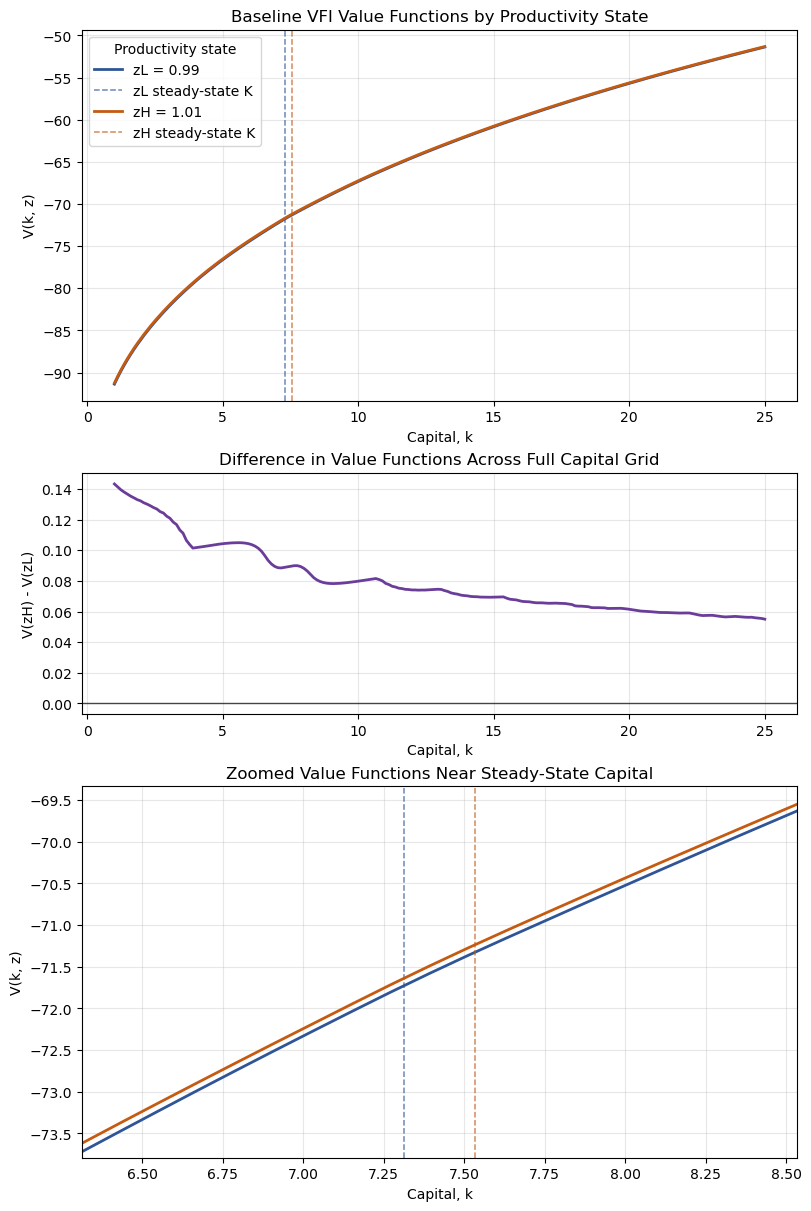

In [24]:
# Value-function plots requested for the VFI baseline diagnostic
fig, axes = plt.subplots(
    3,
    1,
    figsize=(8, 12),
    sharex=False,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1.3, 2]},
)
full_ax, diff_ax, zoom_ax = axes

state_info = [
    (0, "zL", z_states[0], ss_low["K"], "#2f5597"),
    (1, "zH", z_states[1], ss_high["K"], "#c55a11"),
]

for i_z, label, z_val, k_ss, color in state_info:
    full_ax.plot(k_grid, V[:, i_z], linewidth=2.0, color=color, label=f"{label} = {z_val:.2f}")
    full_ax.axvline(k_ss, linestyle="--", linewidth=1.1, color=color, alpha=0.7, label=f"{label} steady-state K")
    zoom_ax.plot(k_grid, V[:, i_z], linewidth=2.0, color=color, label=f"{label} = {z_val:.2f}")
    zoom_ax.axvline(k_ss, linestyle="--", linewidth=1.1, color=color, alpha=0.7, label=f"{label} steady-state K")

# Zoom the value-function panel around the steady-state capital region.
k_zoom_min = max(k_grid[0], min(ss_low["K"], ss_high["K"]) - 1.0)
k_zoom_max = min(k_grid[-1], max(ss_low["K"], ss_high["K"]) + 1.0)
zoom_mask = (k_grid >= k_zoom_min) & (k_grid <= k_zoom_max)
value_min = np.min(V[zoom_mask, :])
value_max = np.max(V[zoom_mask, :])
value_padding = 0.08 * (value_max - value_min)
zoom_ax.set_xlim(k_zoom_min, k_zoom_max)
zoom_ax.set_ylim(value_min - value_padding, value_max + value_padding)

full_ax.set_title("Baseline VFI Value Functions by Productivity State")
full_ax.set_xlabel("Capital, k")
full_ax.set_ylabel("V(k, z)")
full_ax.grid(alpha=0.3)
full_ax.legend(title="Productivity state")

diff_ax.plot(k_grid, V[:, 1] - V[:, 0], linewidth=2.0, color="#6a3d9a")
diff_ax.axhline(0.0, linewidth=1.0, color="black", alpha=0.7)
diff_ax.set_title("Difference in Value Functions Across Full Capital Grid")
diff_ax.set_xlabel("Capital, k")
diff_ax.set_ylabel("V(zH) - V(zL)")
diff_ax.grid(alpha=0.3)

zoom_ax.set_title("Zoomed Value Functions Near Steady-State Capital")
zoom_ax.set_xlabel("Capital, k")
zoom_ax.set_ylabel("V(k, z)")
zoom_ax.grid(alpha=0.3)
plt.show()


## Transition Dynamics
This section builds the full time path after a shock.

Main idea:
- Solve for sequences over time: consumption `C_t`, labor `L_t`, and next-period capital `K_{t+1}`.

How it works:
- `pack_transition_variables` / `unpack_transition_variables` convert between arrays and the vector format needed by `fsolve`.
- `transition_system` stacks all period-by-period conditions:
  - labor condition each period,
  - resource/capital accumulation each period,
  - Euler equations linking today and tomorrow,
  - final (terminal) capital condition.
- `solve_transition_path` solves this system and reconstructs paths for `K`, `C`, `L`, `Y`, and `I`.

In [25]:
# 5. Transition path solver (perfect foresight)

def transition_system(x, K0, z, chi, G_path, terminal_K):
    T_loc       = len(G_path) - 1
    C_path      = x[0           : T_loc+1]
    L_path      = x[T_loc+1     : 2*(T_loc+1)]
    K_next_path = x[2*(T_loc+1) : 3*(T_loc+1)]
    eqs = []

    for t in range(T_loc + 1):
        K_t = K0 if t == 0 else K_next_path[t-1]
        C_t, L_t, G_t = C_path[t], L_path[t], G_path[t]
        if K_t <= 0 or C_t <= 0 or L_t <= 0:
            return np.ones(3*(T_loc+1)) * 1e6
        Y_t = production_function(K_t, L_t, z)
        w_t = marginal_product_labor(K_t, L_t, z)
        eqs.append(chi * (L_t**phi) - w_t * (C_t**(-sigma)))
        eqs.append(Y_t - C_t - G_t - (K_next_path[t] - (1-delta)*K_t))

    for t in range(T_loc):
        rk_tp1 = marginal_product_capital(K_next_path[t], L_path[t+1], z)
        eqs.append((C_path[t]**(-sigma))
                   - beta * (C_path[t+1]**(-sigma)) * (rk_tp1 + 1 - delta))

    eqs.append(K_next_path[T_loc] - terminal_K)
    return np.array(eqs)


def solve_transition(K0, z, chi, G_path, initial_ss, terminal_ss):
    T_loc = len(G_path) - 1
    x0 = np.concatenate([
        np.linspace(initial_ss["C"], terminal_ss["C"], T_loc+1),
        np.linspace(initial_ss["L"], terminal_ss["L"], T_loc+1),
        np.linspace(initial_ss["K"], terminal_ss["K"], T_loc+1),
    ])
    sol = fsolve(transition_system, x0,
                 args=(K0, z, chi, G_path, terminal_ss["K"]),
                 xtol=1e-10, maxfev=50000)

    C_path      = sol[0          : T_loc+1]
    L_path      = sol[T_loc+1    : 2*(T_loc+1)]
    K_next_path = sol[2*(T_loc+1): 3*(T_loc+1)]

    K_path    = np.zeros(T_loc+1)
    K_path[0] = K0
    for t in range(1, T_loc+1):
        K_path[t] = K_next_path[t-1]

    Y_path = np.array([production_function(K_path[t], L_path[t], z)
                       for t in range(T_loc+1)])
    I_path = np.zeros(T_loc+1)
    for t in range(T_loc):
        I_path[t] = K_path[t+1] - (1-delta)*K_path[t]
    I_path[T_loc] = K_next_path[T_loc] - (1-delta)*K_path[T_loc]

    return {"K": K_path, "C": C_path, "L": L_path,
            "Y": Y_path, "I": I_path, "G": G_path}


def prepend_ss(res, ss, n_pre):
    out = {}
    for var in ["C", "L", "Y", "I", "K", "G"]:
        pre = np.full(n_pre, ss[var])
        out[var] = np.concatenate([pre, res[var]])
    return out

# Compatibility alias used in Section 3.3 cells
def solve_transition_path(K0, z, chi, G_path, initial_ss, terminal_ss):
    return solve_transition(K0, z, chi, G_path, initial_ss, terminal_ss)


## Government Spending Shock Paths
This section creates the three shock experiments required in Section 3.2.

1. `make_foreseen_one_time_G_path`
- One temporary increase in `G`, announced in advance at a future date.

2. `make_unforeseen_one_time_G_path`
- One temporary increase in `G` that hits unexpectedly at time 0.

3. `make_permanent_G_path`
- An unexpected increase in `G` at time 0 that stays permanently.



In [26]:
# 6. Government spending paths for Section 3.2

def make_foreseen_path(G_ss, shock_size, lead):
    path = np.full(T_DYN_FOR + 1, G_ss)
    if lead <= T_DYN_FOR:
        path[lead] = G_ss * (1.0 + shock_size)
    return path


def make_unforeseen_onetime_path(G_ss, shock_size):
    path = np.full(T_DYN_UNF + 1, G_ss)
    path[0] = G_ss * (1.0 + shock_size)
    return path


def make_permanent_path(G_ss, shock_size):
    return np.full(T_DYN_UNF + 1, G_ss * (1.0 + shock_size))


# Backward-compatibility wrappers (full-horizon versions)
def make_foreseen_one_time_G_path(G_ss, shock_size, T, shock_date):
    G_path = np.full(T + 1, G_ss)
    G_path[shock_date] = G_ss * (1.0 + shock_size)
    return G_path


def make_unforeseen_one_time_G_path(G_ss, shock_size, T):
    G_path = np.full(T + 1, G_ss)
    G_path[0] = G_ss * (1.0 + shock_size)
    return G_path


def make_permanent_G_path(G_ss, shock_size, T):
    return np.full(T + 1, G_ss * (1.0 + shock_size))


## Plotting Utilities
These helper functions turn raw simulation output into readable figures.

- `percent_deviation`: converts each variable path into percentage deviation from steady state.
- `plot_irfs`: draws impulse response graphs for six variables:
  - Consumption (`C`), Labor (`L`), Investment (`I`), Output (`Y`), Capital (`K`), Government spending (`G`).

How to read the plots:
- 0% line means "back at steady state".
- Positive values mean above normal; negative values mean below normal.


In [27]:
# 7. Plotting

def pct_dev(path, ss_val):
    return 100.0 * (path - ss_val) / ss_val

# Backward-compatibility alias used in Section 3.3 plotting cells
def percent_deviation(path, steady_value):
    return pct_dev(path, steady_value)


def _with_visual_jump(tgrid, y, jump_t, eps=1e-3):
    """
    Keep smooth lines but render a discrete jump exactly at jump_t:
    insert a point at (jump_t-eps, y_{jump_t-1}) before (jump_t, y_{jump_t}).
    """
    t_arr = np.asarray(tgrid, dtype=float)
    y_arr = np.asarray(y, dtype=float)

    if jump_t <= 0 or jump_t >= len(t_arr):
        return t_arr, y_arr

    t_plot = np.insert(t_arr, jump_t, t_arr[jump_t] - eps)
    y_plot = np.insert(y_arr, jump_t, y_arr[jump_t - 1])
    return t_plot, y_plot


def _label_timing_marker(ax, x, text, color, y=1.02, x_offset=0, va="bottom", fontsize=5):
    ax.annotate(
        text,
        xy=(x, y),
        xycoords=ax.get_xaxis_transform(),
        xytext=(x_offset, 0),
        textcoords="offset points",
        fontsize=fontsize,
        color=color,
        fontweight="normal",
        ha="center",
        va=va,
        clip_on=False,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 0.3},
    )


def plot_figure(foreseen_by_lead, res_unforeseen, res_permanent,
                ss, shock_size_pct, save_path=None):

    vars_plot  = [("C", "Consumption"), ("L", "Labour Supply"),
                  ("I", "Investment"),  ("Y", "Output")]
    row_labels = ["(1) Foreseen one-time",
                  "(2) Unforeseen one-time",
                  "(3) Unforeseen permanent"]
    colors     = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    linestyles = ["-", "--", ":"]

    tgrid = np.arange(T_PRE_FOR + T_DYN_FOR + 1)   # 41 points t=0..40

    fig, axes = plt.subplots(
        3, 4, figsize=(15, 9),
        gridspec_kw={"hspace": 0.65, "wspace": 0.38}
    )

    is_benchmark = (shock_size_pct == int(BENCHMARK_SIZE * 100))

    for col, (var, var_label) in enumerate(vars_plot):

        # Row 1: foreseen one-time
        ax = axes[0, col]
        for lead, color, ls in zip(FORESEEN_LEADS, colors, linestyles):
            lw = 2.4 if (lead == BENCHMARK_LEAD and is_benchmark) else 1.6
            label = f"lead={lead}Q"
            full = prepend_ss(foreseen_by_lead[lead], ss, n_pre=T_PRE_FOR)
            y = pct_dev(full[var], ss[var])
            tx, yy = _with_visual_jump(tgrid, y, GROUND_ZERO_FORESEEN)
            ax.plot(tx, yy, label=label, color=color, linewidth=lw, linestyle=ls)

        ax.axvline(GROUND_ZERO_FORESEEN, color="gray", linewidth=0.8,
                   linestyle="--", alpha=0.7)
        _label_timing_marker(ax, GROUND_ZERO_FORESEEN, f"t={GROUND_ZERO_FORESEEN}",
                             color="gray", y=1.03, x_offset=0, fontsize=6)
        ax.axvline(GROUND_ZERO_UNFORESEEN, color="dimgray", linewidth=0.8,
                   linestyle="--", alpha=0.7, ymin=0, ymax=1)
        _label_timing_marker(ax, GROUND_ZERO_UNFORESEEN, f"t={GROUND_ZERO_UNFORESEEN}",
                             color="dimgray", y=-0.04, x_offset=0, va="top", fontsize=6)

        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        ax.set_title(var_label, fontsize=10, fontweight="bold", pad=10)
        if col == 0:
            ax.set_ylabel(row_labels[0] + " | % dev. from SS", fontsize=7.5)
        else:
            ax.set_ylabel("% dev. from SS", fontsize=7.5)
        ax.set_xlabel("t", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=7, title="Foreseen lead",
                  title_fontsize=7, loc="best")

        # Row 2: unforeseen one-time
        ax = axes[1, col]
        full = prepend_ss(res_unforeseen, ss, n_pre=T_PRE_UNF)
        y = pct_dev(full[var], ss[var])
        tx, yy = _with_visual_jump(tgrid, y, GROUND_ZERO_UNFORESEEN)
        ax.plot(tx, yy, color="#1f77b4", linewidth=1.6)
        ax.axvline(GROUND_ZERO_UNFORESEEN, color="dimgray", linewidth=0.8,
                   linestyle="--", alpha=0.7, ymin=0, ymax=1)
        _label_timing_marker(ax, GROUND_ZERO_UNFORESEEN, f"t={GROUND_ZERO_UNFORESEEN}",
                             color="dimgray", y=1.03, x_offset=0, fontsize=6)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        if col == 0:
            ax.set_ylabel(row_labels[1] + " | % dev. from SS", fontsize=7.5)
        else:
            ax.set_ylabel("% dev. from SS", fontsize=7.5)
        ax.set_xlabel("t", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Row 3: unforeseen permanent
        ax = axes[2, col]
        full = prepend_ss(res_permanent, ss, n_pre=T_PRE_UNF)
        y = pct_dev(full[var], ss[var])
        tx, yy = _with_visual_jump(tgrid, y, GROUND_ZERO_UNFORESEEN)
        ax.plot(tx, yy, color="#1f77b4", linewidth=1.6)
        ax.axvline(GROUND_ZERO_UNFORESEEN, color="dimgray", linewidth=0.8,
                   linestyle="--", alpha=0.7, ymin=0, ymax=1)
        _label_timing_marker(ax, GROUND_ZERO_UNFORESEEN, f"t={GROUND_ZERO_UNFORESEEN}",
                             color="dimgray", y=1.03, x_offset=0, fontsize=6)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        if col == 0:
            ax.set_ylabel(row_labels[2] + " | % dev. from SS", fontsize=7.5)
        else:
            ax.set_ylabel("% dev. from SS", fontsize=7.5)
        ax.set_xlabel("t", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"Section 3.2: Government Spending Shock IRFs  -  "
        f"Shock size = {shock_size_pct}% of G_ss",
        fontsize=10, fontweight="bold", y=1.02
    )

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()
    plt.close(fig)


def plot_irfs(results, baseline_ss, title):
    """Legacy helper kept for compatibility."""
    tgrid = np.arange(len(results["C"]))
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    axes = axes.flatten()

    series = [
        ("Consumption", results["C"], baseline_ss["C"]),
        ("Labor",       results["L"], baseline_ss["L"]),
        ("Investment",  results["I"], baseline_ss["I"]),
        ("Output",      results["Y"], baseline_ss["Y"]),
        ("Capital",     results["K"], baseline_ss["K"]),
        ("Government",  results["G"], baseline_ss["G"]),
    ]

    for ax, (name, path, ss_val) in zip(axes, series):
        ax.plot(tgrid, pct_dev(path, ss_val))
        ax.axhline(0.0, linewidth=0.8)
        ax.set_title(name)
        ax.set_xlabel("Time")
        ax.set_ylabel("% dev. from SS")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


## Impulse Response Analysis Run
This cell executes the baseline experiment for one productivity level (`z_sim = z_H = 1.01`).

Workflow in this run:
1. Calibrate `chi` and compute baseline steady state.
2. Build the three government shock paths.
3. Set terminal conditions:
   - temporary shocks return to original steady state,
   - permanent shock converges to a new steady state with higher `G`.
4. Solve transition paths for each shock.
5. Plot IRFs.



--- Shock size = 1% ---
  Foreseen lead=1Q (announced t=4, G hits t=5) done.
  Foreseen lead=5Q (announced t=4, G hits t=9) done.
  Foreseen lead=9Q (announced t=4, G hits t=13) done.
  Unforeseen one-time (G hits t=5) done.
  Unforeseen permanent (G rises t=5) done.
  Saved: fig_01pct.png


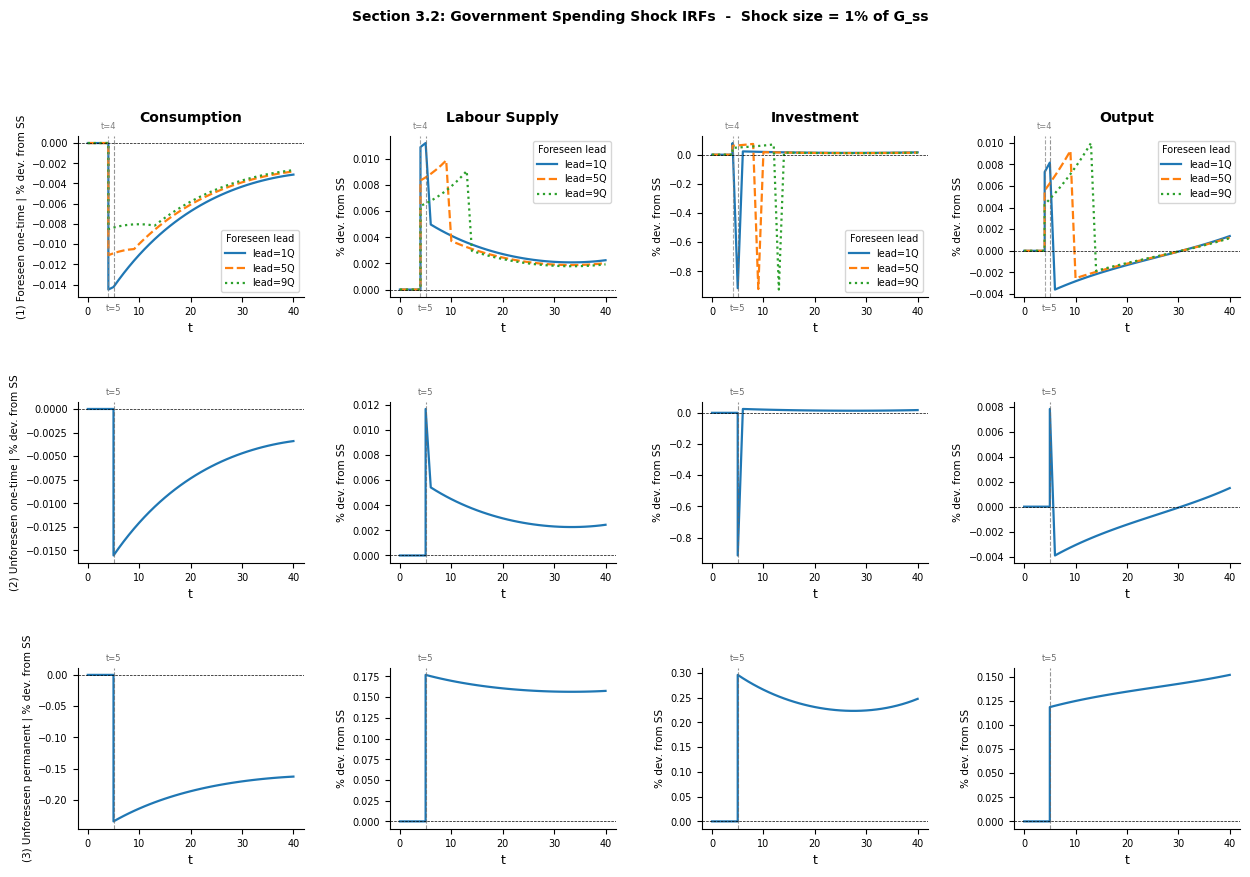


--- Shock size = 5% ---
  Foreseen lead=1Q (announced t=4, G hits t=5) done.
  Foreseen lead=5Q (announced t=4, G hits t=9) done.
  Foreseen lead=9Q (announced t=4, G hits t=13) done.
  Unforeseen one-time (G hits t=5) done.
  Unforeseen permanent (G rises t=5) done.
  Saved: fig_05pct.png


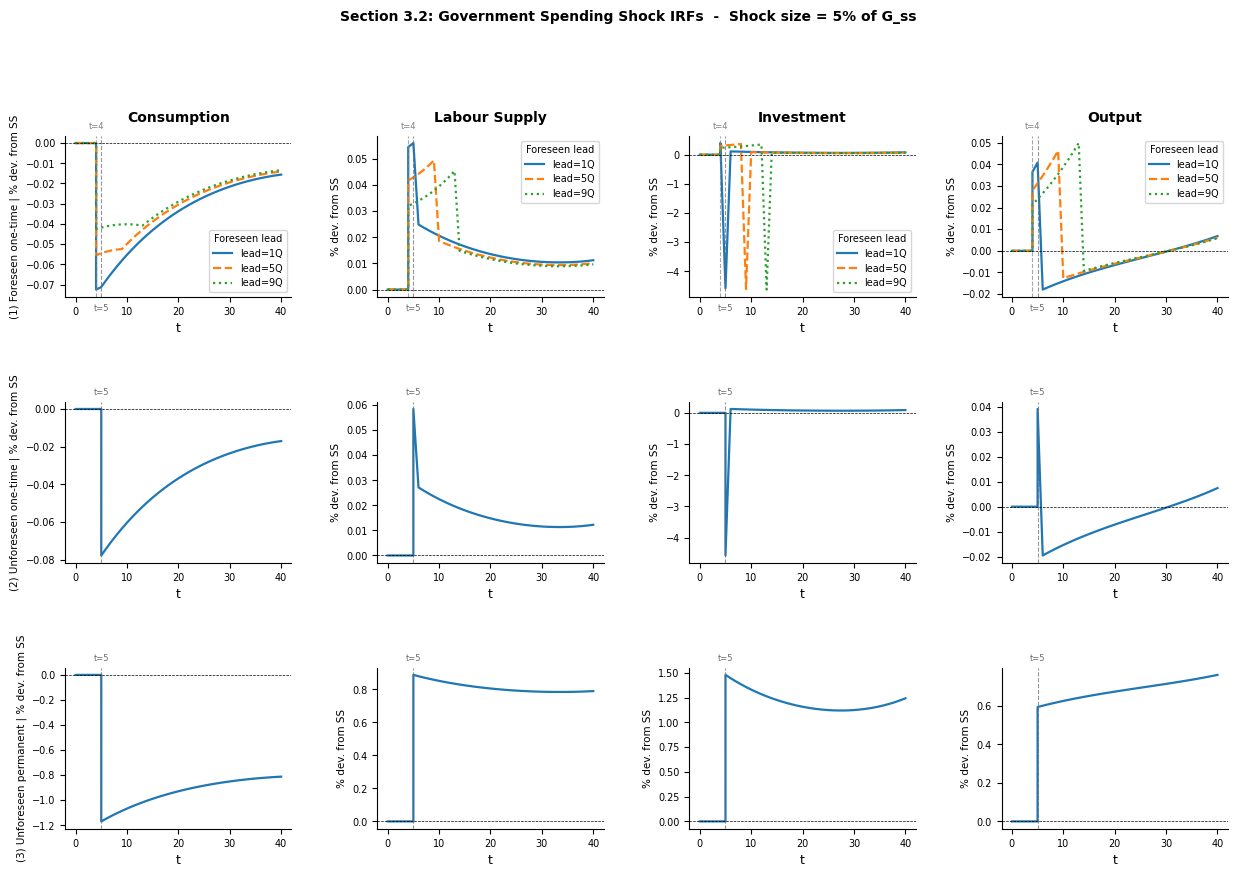


--- Shock size = 10% ---
  Foreseen lead=1Q (announced t=4, G hits t=5) done.
  Foreseen lead=5Q (announced t=4, G hits t=9) done.
  Foreseen lead=9Q (announced t=4, G hits t=13) done.
  Unforeseen one-time (G hits t=5) done.
  Unforeseen permanent (G rises t=5) done.
  Saved: fig_10pct.png


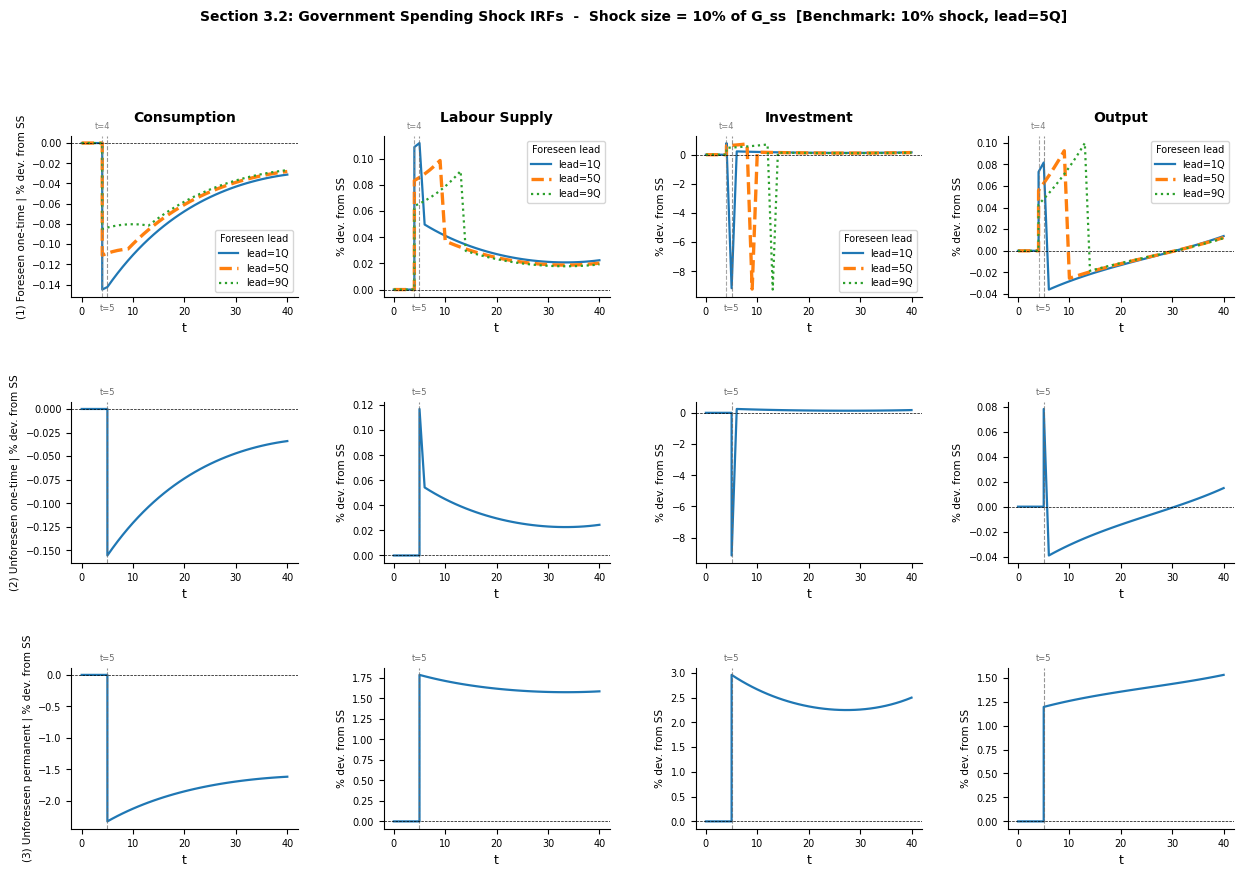


Done. 3 figures saved: fig_01pct.png, fig_05pct.png, fig_10pct.png


In [28]:
# 8. Main: Section 3.2

if __name__ == "__main__":

    # Reuse calibrated values from steady-state cell
    ss_ref = ss_baseline

    G_ss = ss_ref["G"]

    for shock_size in SHOCK_SIZES:
        size_pct = int(shock_size * 100)
        print()
        print(f"--- Shock size = {size_pct}% ---")

        foreseen_by_lead = {}
        for lead in FORESEEN_LEADS:
            G_path = make_foreseen_path(G_ss, shock_size, lead)
            foreseen_by_lead[lead] = solve_transition(
                ss_ref["K"], z_sim, chi, G_path, ss_ref, ss_ref)
            print(f"  Foreseen lead={lead}Q "
                  f"(announced t={GROUND_ZERO_FORESEEN}, "
                  f"G hits t={GROUND_ZERO_FORESEEN+lead}) done.")

        G_unf = make_unforeseen_onetime_path(G_ss, shock_size)
        res_unforeseen = solve_transition(
            ss_ref["K"], z_sim, chi, G_unf, ss_ref, ss_ref)
        print(f"  Unforeseen one-time (G hits t={GROUND_ZERO_UNFORESEEN}) done.")

        terminal_perm = solve_steady_state(
            z_sim, chi, G_ss * (1.0 + shock_size),
            guess=(ss_ref["K"], ss_ref["L"], ss_ref["C"])
        )
        G_perm = make_permanent_path(G_ss, shock_size)
        res_permanent = solve_transition(
            ss_ref["K"], z_sim, chi, G_perm, ss_ref, terminal_perm)
        print(f"  Unforeseen permanent (G rises t={GROUND_ZERO_UNFORESEEN}) done.")

        plot_figure(
            foreseen_by_lead, res_unforeseen, res_permanent,
            ss_ref, size_pct,
            save_path=f"fig_{size_pct:02d}pct.png"
        )

    print()
    print("Done. 3 figures saved: fig_01pct.png, fig_05pct.png, fig_10pct.png")


## Long-Horizon Steady-State Validation (t=120)

This cell keeps the default Section 3.2 setup at `t=40`, then runs a separate long-horizon check up to `t=120` to verify that deviations converge back toward steady state.


Identity check: [0.]
No-shock max |Y dev| (pct points): 5.944343910034284e-11
z_sim, z_H: 1.01 1.01 | match? True


,scenario,var,last_dev_pct,max_abs_tail_pct,avg_tail_slope
0,unforeseen_one_time,C,-0.000547,0.000895,2.489037e-05
1,unforeseen_one_time,Y,0.000239,0.000239,2.419231e-05
2,unforeseen_one_time,K,-0.000073,0.001109,7.401838e-05
3,unforeseen_one_time,L,0.000393,0.000398,-3.491275e-07
4,foreseen_one_time,C,-0.000453,0.000741,2.061347e-05
5,foreseen_one_time,Y,0.000198,0.000198,2.003533e-05
6,foreseen_one_time,K,-0.000060,0.000918,6.129983e-05
7,foreseen_one_time,L,0.000325,0.000330,-2.891341e-07


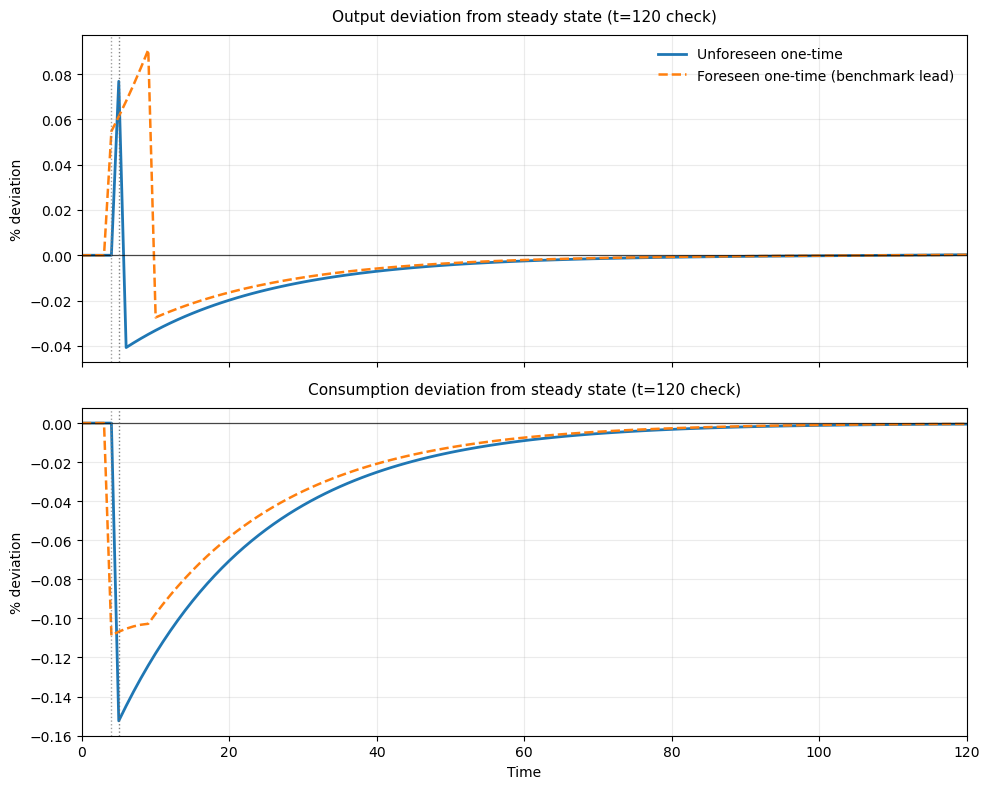

In [ ]:
# Section 3.2 long-horizon (t=120) convergence + full-figure check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = [
    'ss_ref', 'z_sim', 'chi', 'solve_transition', 'solve_steady_state',
    'prepend_ss', 'pct_dev', 'plot_figure',
    'T_PRE_FOR', 'T_PRE_UNF', 'T_DYN_FOR', 'T_DYN_UNF',
    'GROUND_ZERO_FORESEEN', 'GROUND_ZERO_UNFORESEEN',
    'FORESEEN_LEADS', 'BENCHMARK_SIZE', 'BENCHMARK_LEAD', 'SHOCK_SIZES'
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Run the Section 3.2 setup/main cells first. Missing: ' + ', '.join(missing))

T_TARGET = 120
lead_long = BENCHMARK_LEAD if 'BENCHMARK_LEAD' in globals() else 5

T_DYN_LONG_UNF = T_TARGET - T_PRE_UNF
T_DYN_LONG_FOR = T_TARGET - T_PRE_FOR

# 1) No-shock check
print('Identity check:', pct_dev(np.array([ss_ref['Y']]), ss_ref['Y']))
G_no = np.full(T_DYN_LONG_UNF + 1, ss_ref['G'])
res_no_dyn = solve_transition(ss_ref['K'], z_sim, chi, G_no, ss_ref, ss_ref)
res_no = prepend_ss(res_no_dyn, ss_ref, n_pre=T_PRE_UNF)
print('No-shock max |Y dev|:', float(np.max(np.abs(pct_dev(res_no['Y'], ss_ref['Y'])))))

def tail_stats(series, tail=15):
    vals = np.asarray(series[-tail:], dtype=float)
    return float(vals[-1]), float(np.max(np.abs(vals))), float(np.mean(np.diff(vals)))

all_diag_rows = []
_T_DYN_FOR_old, _T_DYN_UNF_old = T_DYN_FOR, T_DYN_UNF

try:
    T_DYN_FOR = T_DYN_LONG_FOR
    T_DYN_UNF = T_DYN_LONG_UNF

    for shock_size_long in SHOCK_SIZES:
        size_pct = int(shock_size_long * 100)
        print(f'\n--- Long-horizon check: shock size = {size_pct}% ---')

        # Foreseen paths
        foreseen_by_lead_long = {}
        for lead in FORESEEN_LEADS:
            G_for = np.full(T_DYN_LONG_FOR + 1, ss_ref['G'])
            if lead <= T_DYN_LONG_FOR:
                G_for[lead] = ss_ref['G'] * (1.0 + shock_size_long)
            foreseen_by_lead_long[lead] = solve_transition(
                ss_ref['K'], z_sim, chi, G_for, ss_ref, ss_ref)

        # Unforeseen one-time
        G_unf_long = np.full(T_DYN_LONG_UNF + 1, ss_ref['G'])
        G_unf_long[0] = ss_ref['G'] * (1.0 + shock_size_long)
        res_unf_long_dyn = solve_transition(
            ss_ref['K'], z_sim, chi, G_unf_long, ss_ref, ss_ref)

        # Unforeseen permanent
        terminal_perm_long = solve_steady_state(
            z_sim, chi, ss_ref['G'] * (1.0 + shock_size_long),
            guess=(ss_ref['K'], ss_ref['L'], ss_ref['C']))
        G_perm_long = np.full(T_DYN_LONG_UNF + 1, ss_ref['G'] * (1.0 + shock_size_long))
        res_perm_long_dyn = solve_transition(
            ss_ref['K'], z_sim, chi, G_perm_long, ss_ref, terminal_perm_long)

        # Prepend for diagnostics
        full_unf_long       = prepend_ss(res_unf_long_dyn, ss_ref, n_pre=T_PRE_UNF)
        full_for_bench_long = prepend_ss(foreseen_by_lead_long[lead_long], ss_ref, n_pre=T_PRE_FOR)
        full_perm_long      = prepend_ss(res_perm_long_dyn, ss_ref, n_pre=T_PRE_UNF)

        # Tail diagnostics
        for name, path in [
            (f'foreseen_lead_{lead_long}', full_for_bench_long),
            ('unforeseen_one_time',        full_unf_long),
            ('unforeseen_permanent',       full_perm_long),
        ]:
            for var in ['C', 'Y', 'K', 'L']:
                dev = pct_dev(path[var], ss_ref[var])
                last_dev, max_tail, avg_slope = tail_stats(dev)
                all_diag_rows.append({
                    'shock_size_pct':    size_pct,
                    'scenario':          name,
                    'var':               var,
                    'last_dev_pct':      last_dev,
                    'max_abs_tail_pct':  max_tail,
                    'avg_tail_slope':    avg_slope,
                })

        # Save figure
        save_name = f'fig_{size_pct:02d}pct_t120.png'
        plot_figure(foreseen_by_lead_long, res_unf_long_dyn, res_perm_long_dyn,
                    ss_ref, size_pct, save_path=save_name)
        print(f'Saved: {save_name}')

finally:
    T_DYN_FOR, T_DYN_UNF = _T_DYN_FOR_old, _T_DYN_UNF_old

diag_long_df = pd.DataFrame(all_diag_rows)
print('\nLong-horizon tail diagnostics (all shock sizes):')
display(diag_long_df)
print('\nDone. Saved: fig_01pct_t120.png, fig_05pct_t120.png, fig_10pct_t120.png')

## State-Dependent Effects

This section extends the Section 3.2 setup to compare fiscal-shock responses across aggregate productivity states. We use two states, $z_L = 0.99$ and $z_H = 1.01$, with transition matrix:

$$
\mathbf{P}_z =
\begin{bmatrix}
0.875 & 0.125 \\ 
0.125 & 0.875
\end{bmatrix}.
$$

To isolate state dependence, we keep the model structure and shock timing conventions from Section 3.2, then run the same three scenarios (foreseen one-time, unforeseen one-time, unforeseen permanent) at each state. The comparison focuses on how response magnitudes and persistence differ between low- and high-productivity conditions.


In [31]:
# Section 3.3 helper: run the same 3.2 experiment conditional on one productivity state

# Optional QuantEcon support (safe fallback if unavailable)
try:
    import quantecon as qe
    HAS_QE = True
except Exception:
    HAS_QE = False

# Two-state aggregate productivity calibration used in Section 3.3
# State order: [zL, zH]. Use the global setup from the VFI/parameter cells when available.
if "z_states" in globals():
    z_L = float(z_states[0])
    z_H = float(z_states[1])
else:
    z_L = 0.99
    z_H = 1.01

if "P_z" not in globals():
    P_z = np.array([
        [0.875, 0.125],
        [0.125, 0.875],
    ])


SECTION33_SCENARIOS = ("foreseen", "unforeseen", "permanent")
SECTION33_SS_KEYS = ("K", "L", "C", "Y", "I", "G")
SECTION33_UPSTREAM_NAMES = (
    "section33_inputs",
    "section33_upstream",
    "markov_section33_inputs",
    "markov_state_results",
    "markov_results",
)


def _canonical_state_key(state_key):
    key = str(state_key).lower().replace("_", "")
    if key in ("low", "zl", "zlow", "l"):
        return "low"
    if key in ("high", "zh", "zhigh", "h"):
        return "high"
    return str(state_key)


def _state_lookup(mapping, state_key):
    if not isinstance(mapping, dict):
        return None
    target = _canonical_state_key(state_key)
    for key, value in mapping.items():
        if _canonical_state_key(key) == target:
            return value
    return None


def _read_key(mapping, *keys, default=None):
    if not isinstance(mapping, dict):
        return default
    for key in keys:
        if key in mapping:
            return mapping[key]
    lower_map = {str(k).lower(): v for k, v in mapping.items()}
    for key in keys:
        key_l = str(key).lower()
        if key_l in lower_map:
            return lower_map[key_l]
    return default


def _normalize_steady_state(ss, state_label):
    if ss is None:
        return None

    out = {}
    for key in ("K", "L", "C", "Y", "I", "G", "w", "rk"):
        val = _read_key(ss, key, key.lower(), default=None)
        if val is not None:
            out[key] = val

    if "I" not in out and "K" in out:
        out["I"] = delta * out["K"]
    if "G" not in out and "Y" in out:
        out["G"] = g_y_ratio * out["Y"]

    missing = [key for key in SECTION33_SS_KEYS if key not in out]
    if missing:
        raise KeyError(f"Section 3.3 upstream steady state for {state_label} is missing: {missing}")
    return out


def _steady_state_from_block(block):
    ss = _read_key(block, "baseline_ss", "ss", "steady_state", default=None)
    if ss is not None:
        return ss
    if any(_read_key(block, key, key.lower(), default=None) is not None for key in ("K", "L", "C", "Y")):
        return block
    return None


def _normalize_results(results):
    if not isinstance(results, dict):
        return {}
    aliases = {
        "foreseen": ("foreseen", "foreseen_one_time", "anticipated", "announced"),
        "unforeseen": ("unforeseen", "unforeseen_one_time", "surprise", "temporary"),
        "permanent": ("permanent", "unforeseen_permanent", "permanent_g", "perm"),
    }
    normalized = {}
    for scenario, names in aliases.items():
        value = _read_key(results, *names, default=None)
        if value is not None:
            normalized[scenario] = value
    return normalized


def _results_from_block(block):
    results = _read_key(block, "results", "irfs", "paths", default=None)
    if results is not None:
        return results
    if isinstance(block, dict) and _normalize_results(block):
        return block
    return None


def find_section33_upstream():
    for name in SECTION33_UPSTREAM_NAMES:
        obj = globals().get(name)
        if isinstance(obj, dict):
            return name, obj
    return None, None


def get_upstream_state_block(upstream, state_key):
    if not isinstance(upstream, dict):
        return {}

    states = _read_key(upstream, "states", "state_results", "by_state", default=None)
    if isinstance(states, dict):
        block = _state_lookup(states, state_key)
        if isinstance(block, dict):
            return block
    elif isinstance(states, (list, tuple)) and len(states) >= 2:
        idx = 0 if _canonical_state_key(state_key) == "low" else 1
        block = states[idx]
        if isinstance(block, dict):
            return block

    if _canonical_state_key(state_key) == "low":
        ss_direct = _read_key(upstream, "low_ss", "ss_low", "zL_ss", "steady_state_low", default=None)
        results_direct = _read_key(upstream, "low_results", "results_low", "zL_results", default=None)
        z_direct = _read_key(upstream, "zL", "z_L", "z_low", default=None)
    else:
        ss_direct = _read_key(upstream, "high_ss", "ss_high", "zH_ss", "steady_state_high", default=None)
        results_direct = _read_key(upstream, "high_results", "results_high", "zH_results", default=None)
        z_direct = _read_key(upstream, "zH", "z_H", "z_high", default=None)
    if ss_direct is not None or results_direct is not None:
        block = {}
        if z_direct is not None:
            block["z"] = z_direct
        if ss_direct is not None:
            block["baseline_ss"] = ss_direct
        if results_direct is not None:
            block["results"] = results_direct
        return block

    block = _state_lookup(upstream, state_key)
    return block if isinstance(block, dict) else {}


def get_upstream_matrix(upstream, default_P):
    P_candidate = _read_key(upstream, "P", "P_z", "transition_matrix", "Pi", default=None)
    if P_candidate is None:
        return np.array(default_P, dtype=float)
    return np.array(P_candidate, dtype=float)


def stationary_distribution_from_matrix(P):
    P_arr = np.array(P, dtype=float)
    vals, vecs = np.linalg.eig(P_arr.T)
    idx = int(np.argmin(np.abs(vals - 1.0)))
    pi = np.real(vecs[:, idx])
    pi = pi / np.sum(pi)
    if np.any(pi < -1e-10):
        pi = np.abs(pi)
        pi = pi / np.sum(pi)
    return pi


def solve_state_steady_with_fixed_chi(z_value, chi_fixed, initial_guess=(10.0, 0.33, 1.0)):
    """
    Solve state steady state with fixed chi and fixed government share rule G = g_y_ratio * Y.
    """
    def steady_state_eq(vars_vec):
        K, L, C = vars_vec

        if K <= 0 or L <= 0 or C <= 0:
            return [1e6, 1e6, 1e6]

        Y = production_function(K, L, z_value)
        w = marginal_product_labor(K, L, z_value)
        rk = marginal_product_capital(K, L, z_value)

        G = g_y_ratio * Y

        eq1 = 1.0 - beta * (rk + 1.0 - delta)
        eq2 = chi_fixed * (L ** phi) - w * (C ** (-sigma))
        eq3 = Y - C - delta * K - G

        return [eq1, eq2, eq3]

    sol = fsolve(steady_state_eq, initial_guess)
    K_ss, L_ss, C_ss = sol

    Y_ss = production_function(K_ss, L_ss, z_value)
    I_ss = delta * K_ss
    G_ss = g_y_ratio * Y_ss
    w_ss = marginal_product_labor(K_ss, L_ss, z_value)
    rk_ss = marginal_product_capital(K_ss, L_ss, z_value)

    return {
        "K": K_ss,
        "L": L_ss,
        "C": C_ss,
        "Y": Y_ss,
        "I": I_ss,
        "G": G_ss,
        "w": w_ss,
        "rk": rk_ss,
    }


def run_state_experiment(
    z_value,
    state_label,
    chi_fixed=None,
    delta_G_abs=None,
    baseline_ss=None,
    results_override=None,
    permanent_ss=None,
):
    # Default to Section 3.2 calibrated chi (global variable from earlier cell)
    if chi_fixed is None:
        if "chi" in globals():
            chi_fixed = chi
        else:
            chi_fixed = calibrate_chi(z=z_sim, L_target=target_L, K_guess=10.0)["chi"]

    # Use upstream state steady state if available; otherwise solve the standalone 3.3 state steady state.
    baseline_ss = _normalize_steady_state(baseline_ss, state_label)
    if baseline_ss is None:
        baseline_ss = solve_state_steady_with_fixed_chi(
            z_value=z_value,
            chi_fixed=chi_fixed,
            initial_guess=(10.0, target_L, 1.0)
        )

    # Default absolute shock size: same absolute ΔG as in Section 3.2 reference
    if delta_G_abs is None:
        if "ss_baseline" in globals():
            delta_G_abs = shock_size * ss_baseline["G"]
        else:
            delta_G_abs = shock_size * baseline_ss["G"]

    G_ss_state = baseline_ss["G"]
    shock_frac = delta_G_abs / G_ss_state

    results = _normalize_results(results_override)

    # (1) Foreseen one-time (benchmark lead), timeline follows Section 3.2
    if "foreseen" not in results:
        lead = BENCHMARK_LEAD
        G_path_foreseen_dyn = make_foreseen_path(G_ss_state, shock_frac, lead)
        results_foreseen_dyn = solve_transition(
            baseline_ss["K"], z_value, chi_fixed,
            G_path_foreseen_dyn, baseline_ss, baseline_ss
        )
        results["foreseen"] = prepend_ss(results_foreseen_dyn, baseline_ss, n_pre=T_PRE_FOR)

    # (2) Unforeseen one-time at t = GROUND_ZERO_UNFORESEEN
    if "unforeseen" not in results:
        G_path_unforeseen_dyn = make_unforeseen_onetime_path(G_ss_state, shock_frac)
        results_unforeseen_dyn = solve_transition(
            baseline_ss["K"], z_value, chi_fixed,
            G_path_unforeseen_dyn, baseline_ss, baseline_ss
        )
        results["unforeseen"] = prepend_ss(results_unforeseen_dyn, baseline_ss, n_pre=T_PRE_UNF)

    # (3) Unforeseen permanent at t = GROUND_ZERO_UNFORESEEN
    if "permanent" not in results:
        G_perm = G_ss_state + delta_G_abs
        permanent_ss = _normalize_steady_state(permanent_ss, f"{state_label} permanent")
        if permanent_ss is None:
            permanent_ss = solve_steady_state_fixed_G(
                z=z_value,
                chi=chi_fixed,
                G_fixed=G_perm,
                initial_guess=(baseline_ss["K"], baseline_ss["L"], baseline_ss["C"])
            )
        G_path_permanent_dyn = make_permanent_path(G_ss_state, shock_frac)
        results_permanent_dyn = solve_transition(
            baseline_ss["K"], z_value, chi_fixed,
            G_path_permanent_dyn, baseline_ss, permanent_ss
        )
        results["permanent"] = prepend_ss(results_permanent_dyn, baseline_ss, n_pre=T_PRE_UNF)

    print()
    print(f"State: {state_label} (z = {z_value:.3f})")
    print(f"Timing -> Foreseen: announce t={GROUND_ZERO_FORESEEN}, benchmark hit t={GROUND_ZERO_FORESEEN + BENCHMARK_LEAD}; Unforeseen hit t={GROUND_ZERO_UNFORESEEN}")
    print(f"Fixed chi: {chi_fixed:.4f} | Common absolute ΔG: {delta_G_abs:.4f}")
    print(f"L: {baseline_ss['L']:.4f}, K: {baseline_ss['K']:.4f}, C: {baseline_ss['C']:.4f}, I: {baseline_ss['I']:.4f}, Y: {baseline_ss['Y']:.4f}, G: {baseline_ss['G']:.4f}")

    return {
        "z": z_value,
        "label": state_label,
        "chi_fixed": chi_fixed,
        "delta_G_abs": delta_G_abs,
        "baseline_ss": baseline_ss,
        "results": results,
    }


def build_section33_experiments(upstream=None, upstream_name=None):
    upstream = upstream or {}
    using_upstream = isinstance(upstream, dict) and len(upstream) > 0

    P_current = get_upstream_matrix(upstream, P_z)
    low_block = get_upstream_state_block(upstream, "low")
    high_block = get_upstream_state_block(upstream, "high")

    z_low = _read_key(low_block, "z", "zL", "z_low", default=_read_key(upstream, "zL", "z_L", "z_low", default=z_L))
    z_high = _read_key(high_block, "z", "zH", "z_high", default=_read_key(upstream, "zH", "z_H", "z_high", default=z_H))

    chi_current = _read_key(upstream, "chi", "chi_fixed", default=globals().get("chi", None))
    if chi_current is None:
        chi_current = calibrate_chi(z=z_sim, L_target=target_L, K_guess=10.0)["chi"]

    delta_G_current = _read_key(upstream, "delta_G_abs", "delta_G", "dG", default=None)
    if delta_G_current is None and "ss_baseline" in globals():
        delta_G_current = shock_size * ss_baseline["G"]

    pi_current = stationary_distribution_from_matrix(P_current)
    z_mean_current = pi_current[0] * z_low + pi_current[1] * z_high

    calibration_name = _read_key(
        upstream,
        "name",
        "calibration_name",
        "label",
        default="Two-state aggregate productivity",
    )

    print("Section 3.3 aggregate productivity setup")
    print(f"input source -> {upstream_name if using_upstream else 'standalone Section 3.3 fallback'}")
    print(f"states -> zL = {z_low:.3f}, zH = {z_high:.3f}")
    print(f"P_z = [[{P_current[0,0]:.3f}, {P_current[0,1]:.3f}], [{P_current[1,0]:.3f}, {P_current[1,1]:.3f}]]")
    print(f"stationary probabilities -> zL: {pi_current[0]:.3f}, zH: {pi_current[1]:.3f}")
    print(f"stationary mean productivity E[z] = {z_mean_current:.3f}")
    print(f"chi used by Section 3.3: {chi_current:.4f}")
    if delta_G_current is not None:
        print(f"common absolute fiscal shock: ΔG = {delta_G_current:.4f}")

    exp_low = run_state_experiment(
        z_low,
        _read_key(low_block, "label", "name", default="Low aggregate productivity"),
        chi_fixed=chi_current,
        delta_G_abs=delta_G_current,
        baseline_ss=_steady_state_from_block(low_block),
        results_override=_results_from_block(low_block),
        permanent_ss=_read_key(low_block, "permanent_ss", "terminal_ss", default=None),
    )
    exp_high = run_state_experiment(
        z_high,
        _read_key(high_block, "label", "name", default="High aggregate productivity"),
        chi_fixed=chi_current,
        delta_G_abs=delta_G_current,
        baseline_ss=_steady_state_from_block(high_block),
        results_override=_results_from_block(high_block),
        permanent_ss=_read_key(high_block, "permanent_ss", "terminal_ss", default=None),
    )

    experiments_out = {
        calibration_name: {
            "low": exp_low,
            "high": exp_high,
            "type": "upstream" if using_upstream else "standalone",
            "source": upstream_name if using_upstream else "Section 3.3 fallback",
            "zL": z_low,
            "zH": z_high,
            "P": P_current,
            "stationary_probs": pi_current,
            "stationary_mean_z": z_mean_current,
        }
    }
    return experiments_out, calibration_name


## Low vs High Aggregate Productivity Run
This section compares state-dependent fiscal responses using the same government-spending shock experiments as in the earlier impulse repsonse analysis run.

Aggregate productivity follows this two-state calibration:
- `zL = 0.99`
- `zH = 1.01`
- transition matrix, with state order `[zL, zH]`:

```python
P_z = [[0.875, 0.125],
       [0.125, 0.875]]
```

Key design choices for 3.3:
- First look for an upstream handoff object such as `section33_inputs`.
- If upstream state steady states are available, use them as the low/high productivity baselines.
- If upstream state-level shock paths are available, use them directly for 3.3 plots and tables.
- If upstream inputs are not available yet, fall back to the standalone Section 3.3 calculation so the notebook still runs.
- Use the same foreseen, unforeseen one-time, and unforeseen permanent government-spending shock labels at `zL` and `zH`.


In [32]:
# Section 3.3: build low/high productivity experiments from upstream inputs if available.
# If no upstream handoff object exists yet, this cell falls back to the current standalone 3.3 calculation.

section33_upstream_name, section33_upstream_obj = find_section33_upstream()
experiments, selected_set = build_section33_experiments(
    upstream=section33_upstream_obj,
    upstream_name=section33_upstream_name,
)

print()
print(f"Selected calibration for detailed IRF plots: {selected_set}")


Section 3.3 aggregate productivity setup
input source -> section33_inputs
states -> zL = 0.990, zH = 1.010
P_z = [[0.875, 0.125], [0.125, 0.875]]
stationary probabilities -> zL: 0.500, zH: 0.500
stationary mean productivity E[z] = 1.000
chi used by Section 3.3: 10.0492
common absolute fiscal shock: ΔG = 0.0188

State: Low aggregate productivity (z = 0.990)
Timing -> Foreseen: announce t=4, benchmark hit t=9; Unforeseen hit t=5
Fixed chi: 10.0492 | Common absolute ΔG: 0.0188
L: 0.3333, K: 7.3131, C: 0.5487, I: 0.1828, Y: 0.9144, G: 0.1829

State: High aggregate productivity (z = 1.010)
Timing -> Foreseen: announce t=4, benchmark hit t=9; Unforeseen hit t=5
Fixed chi: 10.0492 | Common absolute ΔG: 0.0188
L: 0.3333, K: 7.5347, C: 0.5653, I: 0.1884, Y: 0.9421, G: 0.1884

Selected calibration for detailed IRF plots: Endogenous-labor VFI two-state baseline


## Low- High- State Comparison Plots
This section plots the low- and high-productivity responses under the two-state aggregate productivity calibration.

Line styles:
- Solid line: low productivity (`zL = 0.99`)
- Dashed line: high productivity (`zH = 1.01`)


In [33]:

# Section 3.3 plotting helpers

# Fallback in case the 3.2 plotting cell was not run
if "_with_visual_jump" not in globals():
    def _with_visual_jump(tgrid, y, jump_t, eps=1e-3):
        t_arr = np.asarray(tgrid, dtype=float)
        y_arr = np.asarray(y, dtype=float)
        if jump_t <= 0 or jump_t >= len(t_arr):
            return t_arr, y_arr
        t_plot = np.insert(t_arr, jump_t, t_arr[jump_t] - eps)
        y_plot = np.insert(y_arr, jump_t, y_arr[jump_t - 1])
        return t_plot, y_plot


if "_label_timing_marker" not in globals():
    def _label_timing_marker(ax, x, text, color, y=1.02, x_offset=0, va="bottom", fontsize=6):
        ax.annotate(
            text,
            xy=(x, y),
            xycoords=ax.get_xaxis_transform(),
            xytext=(x_offset, 0),
            textcoords="offset points",
            fontsize=fontsize,
            color=color,
            fontweight="normal",
            ha="center",
            va=va,
            clip_on=False,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 0.3},
        )


def _safe_name(text):
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in text).strip("_")


def plot_productivity_pairs_by_scenario(productivity_experiments, group_title, save_figures=False, file_prefix="fig_33_group"):
    """
    Produce 3 figures (foreseen / unforeseen / permanent).
    Each figure is 2x2 (C, L, I, Y), overlaying zL (solid) and zH (dashed).
    """
    vars_plot = [
        ("C", "Consumption"),
        ("L", "Labour Supply"),
        ("I", "Investment"),
        ("Y", "Output"),
    ]

    scenarios = [
        ("foreseen", "Foreseen One-Time G Shock", "foreseen"),
        ("unforeseen", "Unforeseen One-Time G Shock", "unforeseen"),
        ("permanent", "Unforeseen Permanent G Shock", "permanent"),
    ]

    calibration_names = list(productivity_experiments.keys())
    cmap = plt.get_cmap("tab10")

    for shock_key, shock_label, shock_tag in scenarios:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()

        legend_handles = []
        legend_labels = []

        for ax_i, (ax, (var, var_name)) in enumerate(zip(axes, vars_plot)):
            for i, calibration_name in enumerate(calibration_names):
                color = cmap(i % 10)
                data = productivity_experiments[calibration_name]

                low = data["low"]
                high = data["high"]

                low_dev = percent_deviation(low["results"][shock_key][var], low["baseline_ss"][var])
                high_dev = percent_deviation(high["results"][shock_key][var], high["baseline_ss"][var])
                tgrid = np.arange(len(low_dev))

                if shock_key in ("unforeseen", "permanent"):
                    tx_l, yy_l = _with_visual_jump(tgrid, low_dev, GROUND_ZERO_UNFORESEEN)
                    tx_h, yy_h = _with_visual_jump(tgrid, high_dev, GROUND_ZERO_UNFORESEEN)
                else:
                    tx_l, yy_l = _with_visual_jump(tgrid, low_dev, GROUND_ZERO_FORESEEN)
                    tx_h, yy_h = _with_visual_jump(tgrid, high_dev, GROUND_ZERO_FORESEEN)

                h_low, = ax.plot(
                    tx_l, yy_l,
                    color=color, linestyle="-", linewidth=1.7,
                    label=f"zl={data['zL']:.2f}"
                )
                h_high, = ax.plot(
                    tx_h, yy_h,
                    color=color, linestyle="--", linewidth=1.7,
                    label=f"zh={data['zH']:.2f}"
                )

                if ax_i == 0:
                    legend_handles.extend([h_low, h_high])
                    legend_labels.extend([
                        f"zl={data['zL']:.2f}",
                        f"zh={data['zH']:.2f}",
                    ])

            # timing markers, aligned with 3.2 story
            if shock_key == "foreseen":
                t_announce = GROUND_ZERO_FORESEEN
                t_hit = GROUND_ZERO_FORESEEN + BENCHMARK_LEAD
                ax.axvline(t_announce, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
                ax.axvline(t_hit, color="dimgray", linewidth=0.8, linestyle="--", alpha=0.7)
                _label_timing_marker(ax, t_announce, f"t={t_announce}\nannounce",
                                     color="gray", y=1.03, x_offset=0, fontsize=6)
                _label_timing_marker(ax, t_hit, f"t={t_hit}\nhit",
                                     color="dimgray", y=1.03, x_offset=0, fontsize=6)
            else:
                t_unf = GROUND_ZERO_UNFORESEEN
                ax.axvline(t_unf, color="dimgray", linewidth=0.8, linestyle="--", alpha=0.7)
                _label_timing_marker(ax, t_unf, f"t={t_unf}",
                                     color="dimgray", y=1.03, x_offset=0, fontsize=6)

            ax.axhline(0.0, color="black", linewidth=0.8)
            ax.set_title(var_name)
            ax.set_xlabel("Time")
            ax.set_ylabel("% dev. from state SS")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        fig.suptitle(f"3.3: {shock_label} | {group_title}", fontsize=14)
        fig.tight_layout(rect=[0, 0, 0.78, 0.95])
        fig.legend(
            legend_handles,
            legend_labels,
            loc="center left",
            bbox_to_anchor=(0.80, 0.5),
            fontsize=7,
            frameon=False,
        )

        if save_figures:
            fname = f"{file_prefix}_{_safe_name(group_title)}_{_safe_name(shock_tag)}.png"
            fig.savefig(fname, dpi=150, bbox_inches="tight")
            print(f"Saved: {fname}")

        plt.show()
        plt.close(fig)



###  Low vs High Productivity Plots Across Government Shock Scenarios


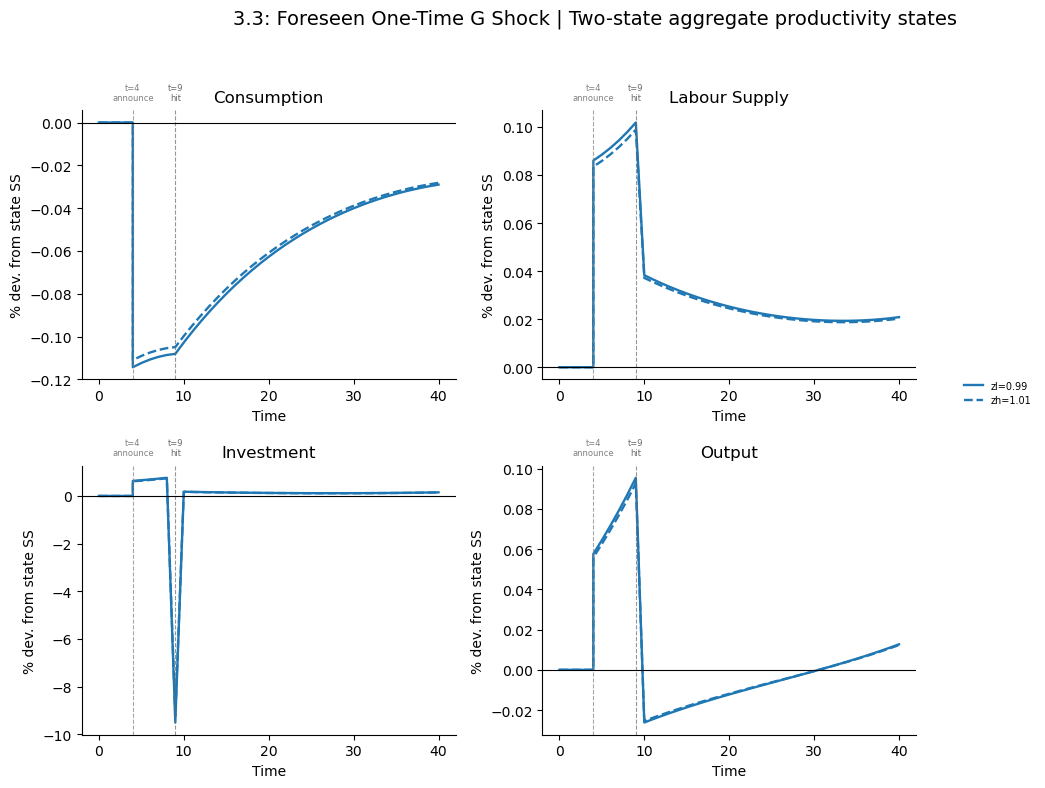

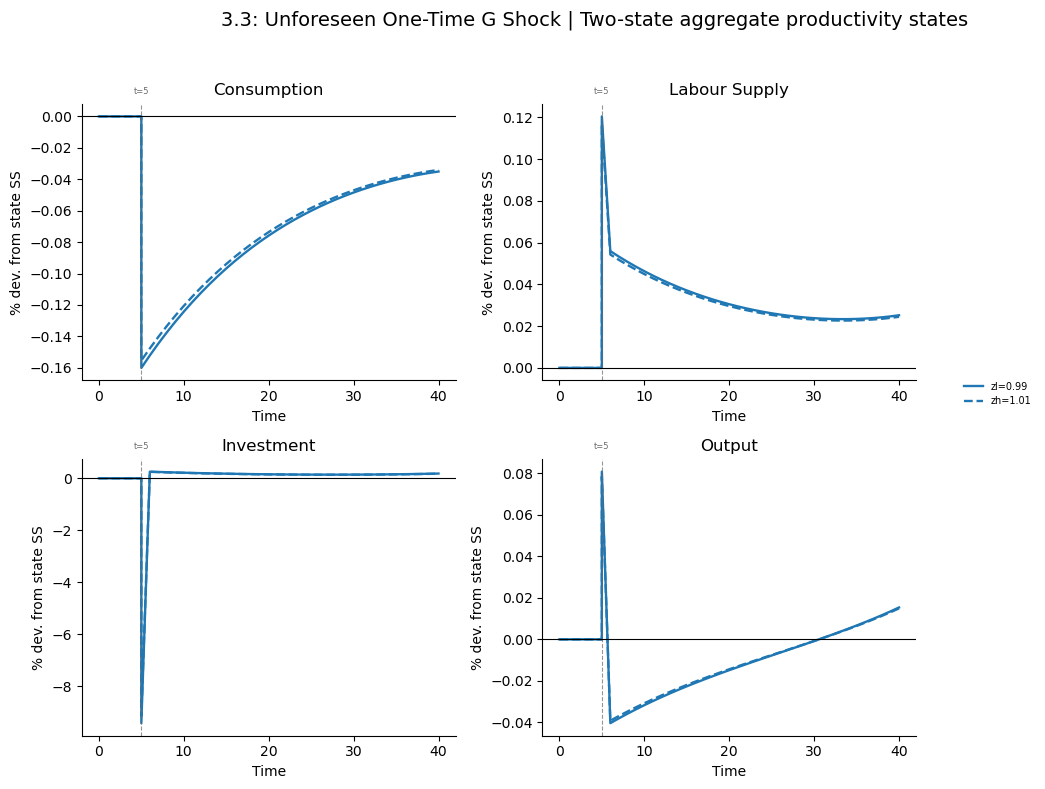

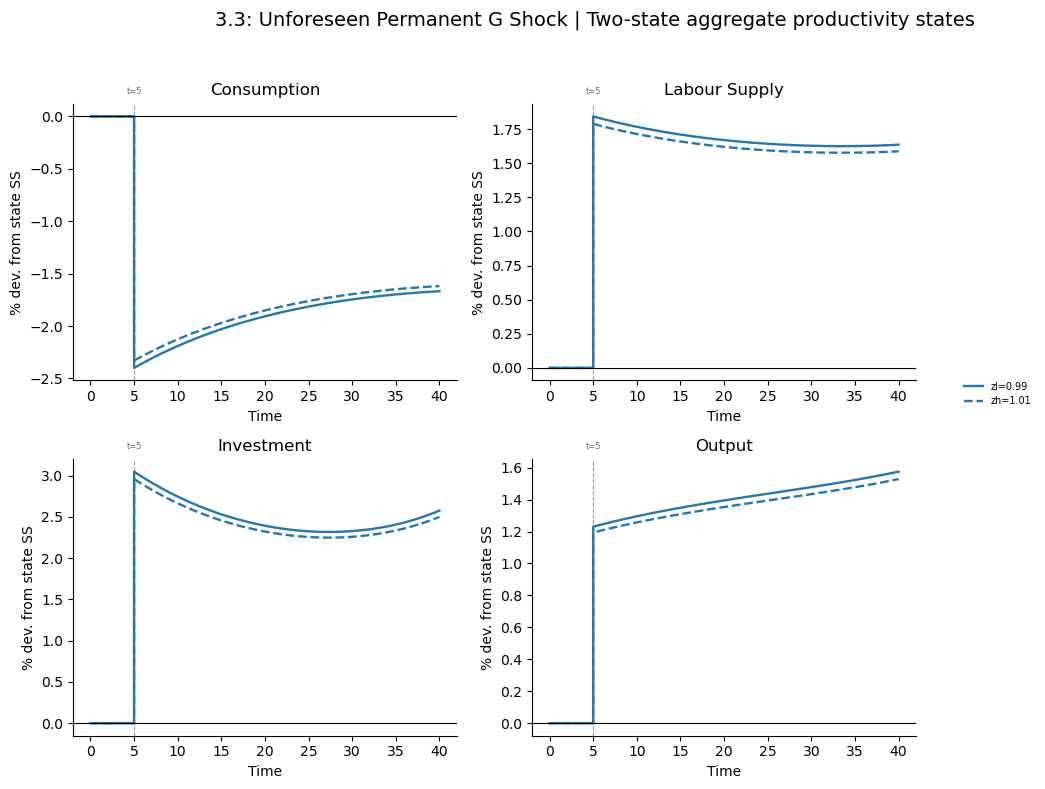

In [34]:
# Low vs high aggregate productivity under the two-state calibration
plot_productivity_pairs_by_scenario(
    experiments,
    group_title="Two-state aggregate productivity states",
    save_figures=False,
    file_prefix="plots/fig_33_productivity",
)


## Low- High- State Output Comparison Table
This table summarizes steady-state outputs for the low- and high-productivity states.

Required outputs shown:
- Output (`Y`)
- Consumption (`C`)
- Investment (`I`)
- Labour (`L`)
- Capital (`K`)


In [35]:
# Section 3.3 output comparison table: one row for zH and one row for zL

if not experiments:
    raise ValueError('No experiments found for Section 3.3 table generation.')

# Use the active (single) calibration setup and report only state rows.
selected_name, set_data = next(iter(experiments.items()))

rows = []
for state_key, state_label in [('high', 'zH'), ('low', 'zL')]:
    ss = set_data[state_key]['baseline_ss']
    rows.append({
        'State': state_label,
        'z': set_data['zH'] if state_key == 'high' else set_data['zL'],
        'Y': ss['Y'],
        'C': ss['C'],
        'I': ss['I'],
        'L': ss['L'],
        'K': ss['K'],
    })

try:
    import pandas as pd
    from IPython.display import display

    df_states = pd.DataFrame(rows)
    df_states = df_states[['State', 'z', 'Y', 'C', 'I', 'L', 'K']]

    print(f'Section 3.3 output comparison (selected calibration: {selected_name})')
    display(df_states.round(4))

except Exception:
    print(f'Section 3.3 output comparison (selected calibration: {selected_name})\n')
    header = f"{'State':5s} {'z':>8s} {'Y':>8s} {'C':>8s} {'I':>8s} {'L':>8s} {'K':>8s}"
    print(header)
    print('-' * len(header))
    for r in rows:
        print(f"{r['State']:5s} {r['z']:8.4f} {r['Y']:8.4f} {r['C']:8.4f} {r['I']:8.4f} {r['L']:8.4f} {r['K']:8.4f}")


Section 3.3 output comparison (selected calibration: Endogenous-labor VFI two-state baseline)


,State,z,Y,C,I,L,K
0,zH,1.01,0.9421,0.5653,0.1884,0.3333,7.5347
1,zL,0.99,0.9144,0.5487,0.1828,0.3333,7.3131


## Scenario Comparison Across `zL` and `zH`
This section compares fiscal-policy responses for both aggregate productivity states under each Section 3.2 government-spending shock scenario.

For each scenario, we report response metrics (in % deviations from state-specific steady state):
- `impact`: response at the shock period
- `peak_abs`: largest absolute response over time
- `avg_0_8`: average response from the shock period to eight periods after the shock

Variables included:
- Output (`Y`), Consumption (`C`), Investment (`I`), Labour (`L`), Capital (`K`)


In [36]:
# Section 3.3 scenario-comparison tables across the two productivity states

scenario_name_map = {
    'foreseen': 'Foreseen one-time',
    'unforeseen': 'Unforeseen one-time',
    'permanent': 'Unforeseen permanent',
}

# shock timing by scenario (aligned with Section 3.2 timeline)
shock_time_map = {
    'foreseen': GROUND_ZERO_FORESEEN + BENCHMARK_LEAD,
    'unforeseen': GROUND_ZERO_UNFORESEEN,
    'permanent': GROUND_ZERO_UNFORESEEN,
}

vars_report = ['Y', 'C', 'I', 'L', 'K']

def irf_metrics(path, steady_state_value, shock_t, avg_horizon=8):
    dev = percent_deviation(path, steady_state_value)
    impact = float(dev[shock_t])
    peak_abs = float(dev[np.argmax(np.abs(dev))])
    end_t = min(len(dev) - 1, shock_t + avg_horizon)
    avg_shock_window = float(np.mean(dev[shock_t:end_t + 1]))
    return impact, peak_abs, avg_shock_window

if not experiments:
    raise ValueError('No experiments found for Section 3.3 scenario table generation.')

# Use the active (single) calibration setup and report only z-state rows.
selected_name, set_data = next(iter(experiments.items()))

rows = []
for state_key, state_label in [('high', 'zH'), ('low', 'zL')]:
    state_block = set_data[state_key]
    ss = state_block['baseline_ss']
    z_val = set_data['zH'] if state_key == 'high' else set_data['zL']

    for scenario_key, scenario_label in scenario_name_map.items():
        res = state_block['results'][scenario_key]
        shock_t = shock_time_map[scenario_key]
        row = {
            'State': state_label,
            'z': z_val,
            'Scenario': scenario_label,
        }

        for var in vars_report:
            impact, peak_abs, avg_shock_0_8 = irf_metrics(
                res[var], ss[var], shock_t=shock_t, avg_horizon=8
            )
            row[f'{var}_impact_%'] = impact
            row[f'{var}_peak_abs_%'] = peak_abs
            row[f'{var}_avg_shock_0_8_%'] = avg_shock_0_8

        rows.append(row)

try:
    import pandas as pd
    from IPython.display import display

    df = pd.DataFrame(rows)
    df['Scenario'] = pd.Categorical(
        df['Scenario'],
        categories=list(scenario_name_map.values()),
        ordered=True,
    )
    df['State'] = pd.Categorical(df['State'], categories=['zH', 'zL'], ordered=True)
    df = df.sort_values(['Scenario', 'State']).reset_index(drop=True)

    print(f'Section 3.3 scenario comparison (selected calibration: {selected_name})')
    for scenario_label in scenario_name_map.values():
        print(f'\n=== {scenario_label} ===')
        sub = df[df['Scenario'] == scenario_label].copy()
        display(sub.round(4))

except Exception:
    print(f'Section 3.3 scenario comparison (selected calibration: {selected_name})\n')
    for scenario_label in scenario_name_map.values():
        print(f'\n=== {scenario_label} ===')
        print(f"{'State':5s} {'z':>7s} {'Y_imp':>8s} {'Y_peak':>8s} {'C_imp':>8s} {'I_imp':>8s}")
        print('-' * 62)
        for r in rows:
            if r['Scenario'] != scenario_label:
                continue
            print(f"{r['State']:5s} {r['z']:7.3f} {r['Y_impact_%']:8.3f} {r['Y_peak_abs_%']:8.3f} {r['C_impact_%']:8.3f} {r['I_impact_%']:8.3f}")


Section 3.3 scenario comparison (selected calibration: Endogenous-labor VFI two-state baseline)

=== Foreseen one-time ===


,State,z,Scenario,Y_impact_%,Y_peak_abs_%,Y_avg_shock_0_8_%,C_impact_%,C_peak_abs_%,C_avg_shock_0_8_%,I_impact_%,I_peak_abs_%,I_avg_shock_0_8_%,L_impact_%,L_peak_abs_%,L_avg_shock_0_8_%,K_impact_%,K_peak_abs_%,K_avg_shock_0_8_%
0,zH,1.01,Foreseen one-time,0.0927,0.0927,-0.0078,-0.1049,-0.1109,-0.0866,-9.2242,-9.2242,-0.8904,0.0988,0.0988,0.0394,0.0802,-0.1524,-0.1035
1,zL,0.99,Foreseen one-time,0.0955,0.0955,-0.0080,-0.1080,-0.1143,-0.0892,-9.5037,-9.5037,-0.9174,0.1018,0.1018,0.0406,0.0826,-0.1570,-0.1066



=== Unforeseen one-time ===


,State,z,Scenario,Y_impact_%,Y_peak_abs_%,Y_avg_shock_0_8_%,C_impact_%,C_peak_abs_%,C_avg_shock_0_8_%,I_impact_%,I_peak_abs_%,I_avg_shock_0_8_%,L_impact_%,L_peak_abs_%,L_avg_shock_0_8_%,K_impact_%,K_peak_abs_%,K_avg_shock_0_8_%
2,zH,1.01,Unforeseen one-time,0.0783,0.0783,-0.0197,-0.1553,-0.1553,-0.1280,-9.1445,-9.1445,-0.8258,0.1170,0.1170,0.0542,0.0,-0.2286,-0.1695
3,zL,0.99,Unforeseen one-time,0.0807,0.0807,-0.0203,-0.1600,-0.1600,-0.1318,-9.4215,-9.4215,-0.8508,0.1205,0.1205,0.0558,0.0,-0.2355,-0.1746



=== Unforeseen permanent ===


,State,z,Scenario,Y_impact_%,Y_peak_abs_%,Y_avg_shock_0_8_%,C_impact_%,C_peak_abs_%,C_avg_shock_0_8_%,I_impact_%,I_peak_abs_%,I_avg_shock_0_8_%,L_impact_%,L_peak_abs_%,L_avg_shock_0_8_%,K_impact_%,K_peak_abs_%,K_avg_shock_0_8_%
4,zH,1.01,Unforeseen permanent,1.1942,1.5285,1.2440,-2.3290,-2.3290,-2.1691,2.9593,2.9593,2.7286,1.7876,1.7876,1.7295,0.0,1.4100,0.2657
5,zL,0.99,Unforeseen permanent,1.2307,1.5752,1.2821,-2.3989,-2.3989,-2.2343,3.0488,3.0488,2.8113,1.8425,1.8425,1.7825,0.0,1.4529,0.2737
